## Data Modelling - Ranking and Content-Base Filtering
### Ranking
In this step, we are going to try Tensorflow recommender framework again for ranking. We are going to use this time ranking. The ranking stage takes the outputs of the retrieval model and fine-tunes them to select the best possible handful of recommendations. Its task is to narrow down the set of items the user may be interested in to a shortlist of likely candidates.

We will follow the first steps as in retrieval (Step-4-Data-Modelling-Retrieval) to create tensorflow datasets and embeddings to use it in our model.
### Content-Base filtering
Content-based filtering is a recommendation system technique that suggests items to users based on the characteristics or "content" of the items and the user's preferences. In the context of a beer recommendation system, content-based filtering would suggest beers to a user based on the features you mentioned: beer name, brewer ID, ABV (Alcohol by Volume), and beer style.

We will also create a model for content base filtering. 

In [2]:
#Install tensor libraries
!pip install -q tensorflow
!pip install -q tensorflow-recommenders
!pip install -q tensorflow-ranking
!pip install -q numpy

import pandas as pd
#load dataframes from csv files created in previous steps
file_path = "dataset/ratebeer_dataset.csv"
df = pd.read_csv(file_path)
file_path_beers = "dataset/ratebeer_beers.csv"
df_beers = pd.read_csv(file_path_beers)

df.info()

import tensorflow as tf
import tensorflow_recommenders as tfrs
from typing import Dict, Text
# Tensorflow dataset for ratings
def get_ratings_in_tensor_dataset(df):
    #Drop review_text as it is quite large to create a tensor dataset
    df_without_review = df.drop(columns=['review_text'])
    ratings = tf.data.Dataset.from_tensor_slices(dict(df_without_review)).map(lambda x: {
        "beer_id": x["beer_id"],
        "beer_name": x["beer_name"],
        "brewer_id": x["brewer_id"],
        "beer_style": x["beer_style"],
        "beer_abv": x["beer_abv"],
        "review_username": x["review_username"],
        "review_overall": x["review_overall"],
        "review_taste": x["review_taste"],
        "review_palate": x["review_palate"],
        "review_appearance": x["review_appearance"],
        "review_aroma": x["review_aroma"]
    })
    return ratings

# Tensorflow dataset for beers
def get_beers_in_tensor_dataset(df_beers):
    beers = tf.data.Dataset.from_tensor_slices(dict(df_beers)).map(lambda x: {
        "beer_id": x["beer_id"],
        "beer_name": x["beer_name"],
        "beer_abv": x["beer_abv"],
        "beer_style": x["beer_style"],
        "brewer_id": x["brewer_id"]
    })
    return beers


# Converting in tensor dataset
ratings = get_ratings_in_tensor_dataset(df)
beers = get_beers_in_tensor_dataset(df_beers)

import numpy as np

def prepare_dictionary_for_embeddings(ratings, beers, embedding_dimension):
    # We need a vocabulary that maps a raw feature value to an integer in a contiguous range
    # this allows us to look up the corresponding embeddings in our embedding tables.
    usernames = ratings.batch(1_000).map(lambda x: x["review_username"])
    unique_usernames = np.unique(np.concatenate(list(usernames)))

    beer_ids = beers.batch(1_000).map(lambda x: x["beer_id"])
    unique_beer_ids = np.unique(np.concatenate(list(beer_ids)))

    # Now add also beer style into the retrieval model
    beer_styles = beers.batch(1_000).map(lambda x: x["beer_style"])
    unique_beer_styles = np.unique(np.concatenate(list(beer_styles)))

    # Now add also beer name into the retrieval model
    beer_names = beers.batch(1_000).map(lambda x: x["beer_name"])
    unique_beer_names = np.unique(np.concatenate(list(beer_styles)))

    #Add beer_abvs, this value will be used in the model too
    beer_abvs = np.concatenate(list(ratings.map(lambda x: x["beer_abv"]).batch(100)))

    max_beer_abv = beer_abvs.max()
    min_beer_abv = beer_abvs.min()

    beer_abv_buckets = np.linspace(
        min_beer_abv, max_beer_abv, num=1000,
    )
    return {
        "embedding_dimension": embedding_dimension,
        "unique_usernames": unique_usernames,
        "unique_beer_ids": unique_beer_ids,
        "unique_beer_styles": unique_beer_styles,
        "unique_beer_names": unique_beer_names,
        "beer_abv_buckets": beer_abv_buckets
    }

#Let's start with embedding size 32
embedding_dicts = prepare_dictionary_for_embeddings(ratings, beers, 32)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 308103 entries, 0 to 308102
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype  
---  ------             --------------   -----  
 0   beer_name          308103 non-null  object 
 1   beer_id            308103 non-null  int64  
 2   brewer_id          308103 non-null  int64  
 3   beer_abv           308103 non-null  float64
 4   beer_style         308103 non-null  object 
 5   review_appearance  308103 non-null  float64
 6   review_aroma       308103 non-null  float64
 7   review_palate      308103 non-null  float64
 8   review_taste       308103 non-null  float64
 9   review_overall     308103 non-null  float64
 10  review_time        308103 non-null  int64  
 11  review_username    308103 non-null  object 
 12  review_text        307302 non-null  object 
 13  review_count       308103 non-null  int64  
dtypes: float64(6), int64(4), object(4)
memory usage: 32.9+ MB



#### Ranking models
The model is designed to create a machine learning model for ranking beers based on user preferences. 

The target value is the overall rating of the user. Like in retrieval we are using embeddings here. 

The embeddings are the entry point of the model. They have username, beer names, beer styles depending on the version of the model.

At the end of the embedding layer, we have sequential layer with a size of 256 x 64 neural network for predicting the overall rating. We are using "relu" as an activation function. 


In [11]:
class RankingModelV1(tf.keras.Model):

  def __init__(self, unique_usernames, unique_beer_ids, embedding_dimension):
    super().__init__()

    # Compute embeddings for users.
    self.username_embeddings = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=unique_usernames, mask_token=None),
      tf.keras.layers.Embedding(len(unique_usernames) + 1, embedding_dimension)
    ])

    # Compute embeddings for beers.
    self.beer_id_embeddings = tf.keras.Sequential([
      tf.keras.layers.IntegerLookup(
        vocabulary=unique_beer_ids, mask_token=None),
      tf.keras.layers.Embedding(len(unique_beer_ids) + 1, embedding_dimension)
    ])

    # Compute predictions.
    self.ratings = tf.keras.Sequential([
      # Learn multiple dense layers.
      tf.keras.layers.Dense(256, activation="relu"),
      tf.keras.layers.Dense(64, activation="relu"),
      # Make rating predictions in the final layer.
      tf.keras.layers.Dense(1)
  ])

  def call(self, inputs):

    username, beer_id = inputs

    username_embedding = self.username_embeddings(username)
    beerid_embedding = self.beer_id_embeddings(beer_id)

    return self.ratings(tf.concat([username_embedding, beerid_embedding], axis=1))

class BeerRankingModelV1(tfrs.models.Model):

  def __init__(self, dicts):
    super().__init__()
    self.ranking_model: tf.keras.Model = RankingModelV1(dicts['unique_usernames'], dicts['unique_beer_ids'], dicts['embedding_dimension'])
    self.task: tf.keras.layers.Layer = tfrs.tasks.Ranking(
      loss = tf.keras.losses.MeanSquaredError(),
      metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )

  def call(self, features: Dict[str, tf.Tensor]) -> tf.Tensor:
    return self.ranking_model(
        (features["review_username"], features["beer_id"]))

  def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
    labels = features.pop("review_overall")

    rating_predictions = self(features)

    # The task computes the loss and the metrics.
    return self.task(labels=labels, predictions=rating_predictions)
  def get_model_name(self):
        return "BeerRankingModelV1"

In [12]:
class RankingModelV2(tf.keras.Model):

  def __init__(self, unique_usernames, unique_beer_ids, unique_beer_styles, embedding_dimension):
    super().__init__()

    # Compute embeddings for users.
    self.username_embeddings = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=unique_usernames, mask_token=None),
      tf.keras.layers.Embedding(len(unique_usernames) + 1, embedding_dimension)
    ])

    # Compute embeddings for beers.
    self.beer_id_embeddings = tf.keras.Sequential([
      tf.keras.layers.IntegerLookup(
        vocabulary=unique_beer_ids, mask_token=None),
      tf.keras.layers.Embedding(len(unique_beer_ids) + 1, embedding_dimension)
    ])
    
    # Compute embeddings for beer styles.
    self.beer_style_embeddings = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=unique_beer_styles, mask_token=None),
      tf.keras.layers.Embedding(len(unique_beer_styles) + 1, embedding_dimension)
    ])

    # Compute predictions.
    self.ratings = tf.keras.Sequential([
      # Learn multiple dense layers.
      tf.keras.layers.Dense(256, activation="relu"),
      tf.keras.layers.Dense(64, activation="relu"),
      # Make rating predictions in the final layer.
      tf.keras.layers.Dense(1)
  ])

  def call(self, inputs):

    username, beer_id, beer_style = inputs

    username_embedding = self.username_embeddings(username)
    beerid_embedding = self.beer_id_embeddings(beer_id)
    beer_style_embedding = self.beer_style_embeddings(beer_style)

    return self.ratings(tf.concat([username_embedding, beerid_embedding, beer_style_embedding], axis=1))

class BeerRankingModelV2(tfrs.models.Model):

  def __init__(self, dicts):
    super().__init__()
    self.ranking_model: tf.keras.Model = RankingModelV2(dicts['unique_usernames'], dicts['unique_beer_ids'], dicts['unique_beer_styles'], dicts['embedding_dimension'])
    self.task: tf.keras.layers.Layer = tfrs.tasks.Ranking(
      loss = tf.keras.losses.MeanSquaredError(),
      metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )

  def call(self, features: Dict[str, tf.Tensor]) -> tf.Tensor:
    return self.ranking_model(
        (features["review_username"], features["beer_id"], features["beer_style"]))

  def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
    labels = features.pop("review_overall")

    rating_predictions = self(features)

    # The task computes the loss and the metrics.
    return self.task(labels=labels, predictions=rating_predictions)
  def get_model_name(self):
        return "BeerRankingModelV2"

In [13]:
class RankingModelV3(tf.keras.Model):

  def __init__(self, unique_usernames, unique_beer_ids, unique_beer_names, unique_beer_styles, embedding_dimension):
    super().__init__()

    # Compute embeddings for users.
    self.username_embeddings = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=unique_usernames, mask_token=None),
      tf.keras.layers.Embedding(len(unique_usernames) + 1, embedding_dimension)
    ])

    # Compute embeddings for beers.
    self.beer_id_embeddings = tf.keras.Sequential([
      tf.keras.layers.IntegerLookup(
        vocabulary=unique_beer_ids, mask_token=None),
      tf.keras.layers.Embedding(len(unique_beer_ids) + 1, embedding_dimension)
    ])
    
    # Compute embeddings for beer names.
    self.beer_name_embeddings = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=unique_beer_names, mask_token=None),
      tf.keras.layers.Embedding(len(unique_beer_names) + 1, embedding_dimension)
    ])
    
    # Compute embeddings for beer styles.
    self.beer_style_embeddings = tf.keras.Sequential([
      tf.keras.layers.StringLookup(
        vocabulary=unique_beer_styles, mask_token=None),
      tf.keras.layers.Embedding(len(unique_beer_styles) + 1, embedding_dimension)
    ])

    # Compute predictions.
    self.ratings = tf.keras.Sequential([
      # Learn multiple dense layers.
      tf.keras.layers.Dense(256, activation="relu"),
      tf.keras.layers.Dense(64, activation="relu"),
      # Make rating predictions in the final layer.
      tf.keras.layers.Dense(1)
  ])

  def call(self, inputs):

    username, beer_id, beer_name, beer_style = inputs

    username_embedding = self.username_embeddings(username)
    beerid_embedding = self.beer_id_embeddings(beer_id)
    beer_name_embedding = self.beer_name_embeddings(beer_name)
    beer_style_embedding = self.beer_style_embeddings(beer_style)

    return self.ratings(tf.concat([username_embedding, beerid_embedding, beer_name_embedding, beer_style_embedding], axis=1))

class BeerRankingModelV3(tfrs.models.Model):

  def __init__(self, dicts):
    super().__init__()
    self.ranking_model: tf.keras.Model = RankingModelV3(dicts['unique_usernames'], dicts['unique_beer_ids'], dicts['unique_beer_names'], dicts['unique_beer_styles'], dicts['embedding_dimension'])
    self.task: tf.keras.layers.Layer = tfrs.tasks.Ranking(
      loss = tf.keras.losses.MeanSquaredError(),
      metrics=[tf.keras.metrics.RootMeanSquaredError()]
    )

  def call(self, features: Dict[str, tf.Tensor]) -> tf.Tensor:
    return self.ranking_model(
        (features["review_username"], features["beer_id"],features["beer_name"], features["beer_style"]))

  def compute_loss(self, features: Dict[Text, tf.Tensor], training=False) -> tf.Tensor:
    labels = features.pop("review_overall")

    rating_predictions = self(features)

    # The task computes the loss and the metrics.
    return self.task(labels=labels, predictions=rating_predictions)
  def get_model_name(self):
        return "BeerRankingModelV3"

#### Evaluation of models
In the next cell, we will have some methods to gather metrics for the given model. So that we can see all the hyper parameters affecting the model accuracy

Different from retrieval, the ranking model checks root_mean_squared_error for the accuracy of the model. 

RMSE is the square root of the average of squared differences between the predicted values and the actual values. Smaller the value more accurate it is. 

In [6]:
def get_training_metrics_ranking(hyper_params, training_results, model_name):
    # Get the total number of epochs
    total_epochs = len(training_results.history['loss'])

    # Retrieve metrics from the last epoch
    last_epoch = total_epochs - 1
    root_mean_squared_error = training_results.history['root_mean_squared_error'][last_epoch]
    loss = training_results.history['loss'][last_epoch]
    total_loss = training_results.history['total_loss'][last_epoch]
    learning_rate = hyper_params["learning_rate"]

    metrics_dict = {
        'model_name': model_name,
        'epochs': total_epochs,
        'learning_rate': learning_rate,
        'root_mean_squared_error': root_mean_squared_error,
        'loss': loss,
        'total_loss': total_loss,
        'is_training': True
    }
    return metrics_dict

def get_test_metrics_ranking(hyper_params, test_result, model_name):
    root_mean_squared_error = test_result['root_mean_squared_error']
    loss = test_result['loss']
    total_loss = test_result['total_loss']
    number_of_epochs = hyper_params["epochs"]
    learning_rate = hyper_params["learning_rate"]

    metrics_dict = {
        'model_name': model_name,
        'epochs': number_of_epochs,
        'learning_rate': learning_rate,
        'root_mean_squared_error': root_mean_squared_error,
        'loss': loss,
        'total_loss': total_loss,
        'is_training': False
    }
    return metrics_dict;

#### Fitting the model
Now we can fit the models and see which one is doing the best. 

In [8]:
def get_train_test_cached(ratings, sample_size, batch_size=500):
    tf.random.set_seed(42)
    shuffled = ratings.shuffle(sample_size, seed=42, reshuffle_each_iteration=False)
    train_size = int(sample_size * 0.8)
    test_size = int(sample_size * 0.2)
    train = shuffled.take(train_size)
    test = shuffled.skip(train_size).take(test_size)
    print(f"The sample has a size of {sample_size}. Training size is {train_size}, test size is {test_size} and batch size is{batch_size}" )

    #Cache the dataset for better performance 
    cached_train = train.shuffle(train_size).batch(batch_size).cache()
    cached_test = test.batch(int(batch_size/4)).cache()
    return cached_train, cached_test

In [28]:
sample_size = 308103 #Everything
learning_rates = [0.1, 0.01]
epochs=[10,50,100]

cached_train, cached_test = get_train_test_cached(ratings, sample_size, batch_size=15000)

model_rankings = [
    BeerRankingModelV1(embedding_dicts),
    BeerRankingModelV2(embedding_dicts),
    BeerRankingModelV3(embedding_dicts)
]


ranking_metrics_list = []
for model_ranking in model_rankings:
    for learning_rate in learning_rates:
        for epoch in epochs:
            model_ranking.compile(optimizer=tf.keras.optimizers.Adagrad(learning_rate=learning_rate))
            print('Model name:', model_ranking.get_model_name())

            callback = tf.keras.callbacks.EarlyStopping(monitor='root_mean_squared_error', patience=3, min_delta = 0.0005)

            training_results = model_ranking.fit(cached_train, epochs=epoch, verbose=1, callbacks=callback)
            training_metrics = get_training_metrics_ranking({"learning_rate" : learning_rate, "epochs": epoch}, training_results, model_ranking.get_model_name())
            ranking_metrics_list.append(training_metrics)

            test_result = model_ranking.evaluate(cached_test, return_dict=True, verbose=1)
            test_metrics = get_test_metrics_ranking({"learning_rate" : learning_rate, "epochs": epoch}, test_result, model_ranking.get_model_name())
            ranking_metrics_list.append(test_metrics)

df_rankings_metrics = pd.DataFrame(ranking_metrics_list) 
df_rankings_metrics

The sample has a size of 308103. Training size is 246482, test size is 61620 and batch size is15000
Model name: BeerRankingModelV1
Epoch 1/10
17/17 [==============================] - 6s 109ms/step - root_mean_squared_error: 1.7339 - loss: 2.8071 - regularization_loss: 0.0000e+00 - total_loss: 2.8071
Epoch 2/10
17/17 [==============================] - 0s 20ms/step - root_mean_squared_error: 0.7922 - loss: 0.6162 - regularization_loss: 0.0000e+00 - total_loss: 0.6162
Epoch 3/10
17/17 [==============================] - 0s 20ms/step - root_mean_squared_error: 0.6075 - loss: 0.3653 - regularization_loss: 0.0000e+00 - total_loss: 0.3653
Epoch 4/10
17/17 [==============================] - 0s 20ms/step - root_mean_squared_error: 0.5597 - loss: 0.3136 - regularization_loss: 0.0000e+00 - total_loss: 0.3136
Epoch 5/10
17/17 [==============================] - 0s 20ms/step - root_mean_squared_error: 0.5564 - loss: 0.3101 - regularization_loss: 0.0000e+00 - total_loss: 0.3101
Epoch 6/10
17/17 [=====

17/17 [==============================] - 0s 22ms/step - root_mean_squared_error: 0.5165 - loss: 0.2666 - regularization_loss: 0.0000e+00 - total_loss: 0.2666
Epoch 38/50
17/17 [==============================] - 0s 22ms/step - root_mean_squared_error: 0.5160 - loss: 0.2660 - regularization_loss: 0.0000e+00 - total_loss: 0.2660
Epoch 39/50
17/17 [==============================] - 0s 21ms/step - root_mean_squared_error: 0.5155 - loss: 0.2655 - regularization_loss: 0.0000e+00 - total_loss: 0.2655
Epoch 40/50
17/17 [==============================] - 0s 21ms/step - root_mean_squared_error: 0.5150 - loss: 0.2650 - regularization_loss: 0.0000e+00 - total_loss: 0.2650
Epoch 41/50
17/17 [==============================] - 0s 21ms/step - root_mean_squared_error: 0.5146 - loss: 0.2645 - regularization_loss: 0.0000e+00 - total_loss: 0.2645
Epoch 42/50
17/17 [==============================] - 0s 21ms/step - root_mean_squared_error: 0.5142 - loss: 0.2641 - regularization_loss: 0.0000e+00 - total_loss:

17/17 [==============================] - 0s 3ms/step - root_mean_squared_error: 0.5171 - loss: 0.2667 - regularization_loss: 0.0000e+00 - total_loss: 0.2667
Model name: BeerRankingModelV2
Epoch 1/10
17/17 [==============================] - 1s 22ms/step - root_mean_squared_error: 1.6310 - loss: 2.4844 - regularization_loss: 0.0000e+00 - total_loss: 2.4844
Epoch 2/10
17/17 [==============================] - 0s 21ms/step - root_mean_squared_error: 0.6626 - loss: 0.4341 - regularization_loss: 0.0000e+00 - total_loss: 0.4341
Epoch 3/10
17/17 [==============================] - 0s 22ms/step - root_mean_squared_error: 0.5944 - loss: 0.3528 - regularization_loss: 0.0000e+00 - total_loss: 0.3528
Epoch 4/10
17/17 [==============================] - 0s 26ms/step - root_mean_squared_error: 0.5763 - loss: 0.3322 - regularization_loss: 0.0000e+00 - total_loss: 0.3322
Epoch 5/10
17/17 [==============================] - 0s 23ms/step - root_mean_squared_error: 0.5668 - loss: 0.3214 - regularization_loss:

17/17 [==============================] - 0s 22ms/step - root_mean_squared_error: 0.5195 - loss: 0.2697 - regularization_loss: 0.0000e+00 - total_loss: 0.2697
Epoch 12/100
17/17 [==============================] - 0s 21ms/step - root_mean_squared_error: 0.5188 - loss: 0.2689 - regularization_loss: 0.0000e+00 - total_loss: 0.2689
Epoch 13/100
17/17 [==============================] - 0s 22ms/step - root_mean_squared_error: 0.5181 - loss: 0.2682 - regularization_loss: 0.0000e+00 - total_loss: 0.2682
Epoch 14/100
17/17 [==============================] - 0s 22ms/step - root_mean_squared_error: 0.5175 - loss: 0.2676 - regularization_loss: 0.0000e+00 - total_loss: 0.2676
Epoch 15/100
17/17 [==============================] - 0s 21ms/step - root_mean_squared_error: 0.5169 - loss: 0.2670 - regularization_loss: 0.0000e+00 - total_loss: 0.2670
Epoch 16/100
17/17 [==============================] - 0s 22ms/step - root_mean_squared_error: 0.5164 - loss: 0.2664 - regularization_loss: 0.0000e+00 - total_

17/17 [==============================] - 1s 31ms/step - root_mean_squared_error: 0.5561 - loss: 0.3095 - regularization_loss: 0.0000e+00 - total_loss: 0.3095
Epoch 4/50
17/17 [==============================] - 1s 33ms/step - root_mean_squared_error: 0.5533 - loss: 0.3067 - regularization_loss: 0.0000e+00 - total_loss: 0.3067
Epoch 5/50
17/17 [==============================] - 1s 32ms/step - root_mean_squared_error: 0.5528 - loss: 0.3061 - regularization_loss: 0.0000e+00 - total_loss: 0.3061
Epoch 6/50
17/17 [==============================] - 1s 31ms/step - root_mean_squared_error: 0.5523 - loss: 0.3055 - regularization_loss: 0.0000e+00 - total_loss: 0.3055
Epoch 7/50
17/17 [==============================] - 0s 27ms/step - root_mean_squared_error: 0.5518 - loss: 0.3050 - regularization_loss: 0.0000e+00 - total_loss: 0.3050
Epoch 8/50
17/17 [==============================] - 0s 28ms/step - root_mean_squared_error: 0.5514 - loss: 0.3045 - regularization_loss: 0.0000e+00 - total_loss: 0.30

17/17 [==============================] - 1s 30ms/step - root_mean_squared_error: 0.5230 - loss: 0.2735 - regularization_loss: 0.0000e+00 - total_loss: 0.2735
Epoch 3/100
17/17 [==============================] - 0s 29ms/step - root_mean_squared_error: 0.5229 - loss: 0.2734 - regularization_loss: 0.0000e+00 - total_loss: 0.2734
Epoch 4/100
17/17 [==============================] - 0s 4ms/step - root_mean_squared_error: 0.5275 - loss: 0.2780 - regularization_loss: 0.0000e+00 - total_loss: 0.2780


,model_name,epochs,learning_rate,root_mean_squared_error,loss,total_loss,is_training
0,BeerRankingModelV1,10,0.10,0.553730,0.312003,0.312003,True
1,BeerRankingModelV1,10,0.10,0.552492,0.302465,0.302465,False
2,BeerRankingModelV1,50,0.10,0.511598,0.257276,0.257276,True
3,BeerRankingModelV1,50,0.10,0.519295,0.262314,0.262314,False
4,BeerRankingModelV1,18,0.10,0.508745,0.252562,0.252562,True
5,BeerRankingModelV1,100,0.10,0.517329,0.259145,0.259145,False
6,BeerRankingModelV1,4,0.01,0.508188,0.250391,0.250391,True
7,BeerRankingModelV1,10,0.01,0.517233,0.259120,0.259120,False
8,BeerRankingModelV1,4,0.01,0.508117,0.250409,0.250409,True
9,BeerRankingModelV1,50,0.01,0.517182,0.259070,0.259070,False


#### Model performance
In the next cells, we are going to show the models performance with respect to hyperparameters. 

It will help us to choose the best model with best hyperparameters


In [31]:
!pip install matplotlib
!pip install seaborn

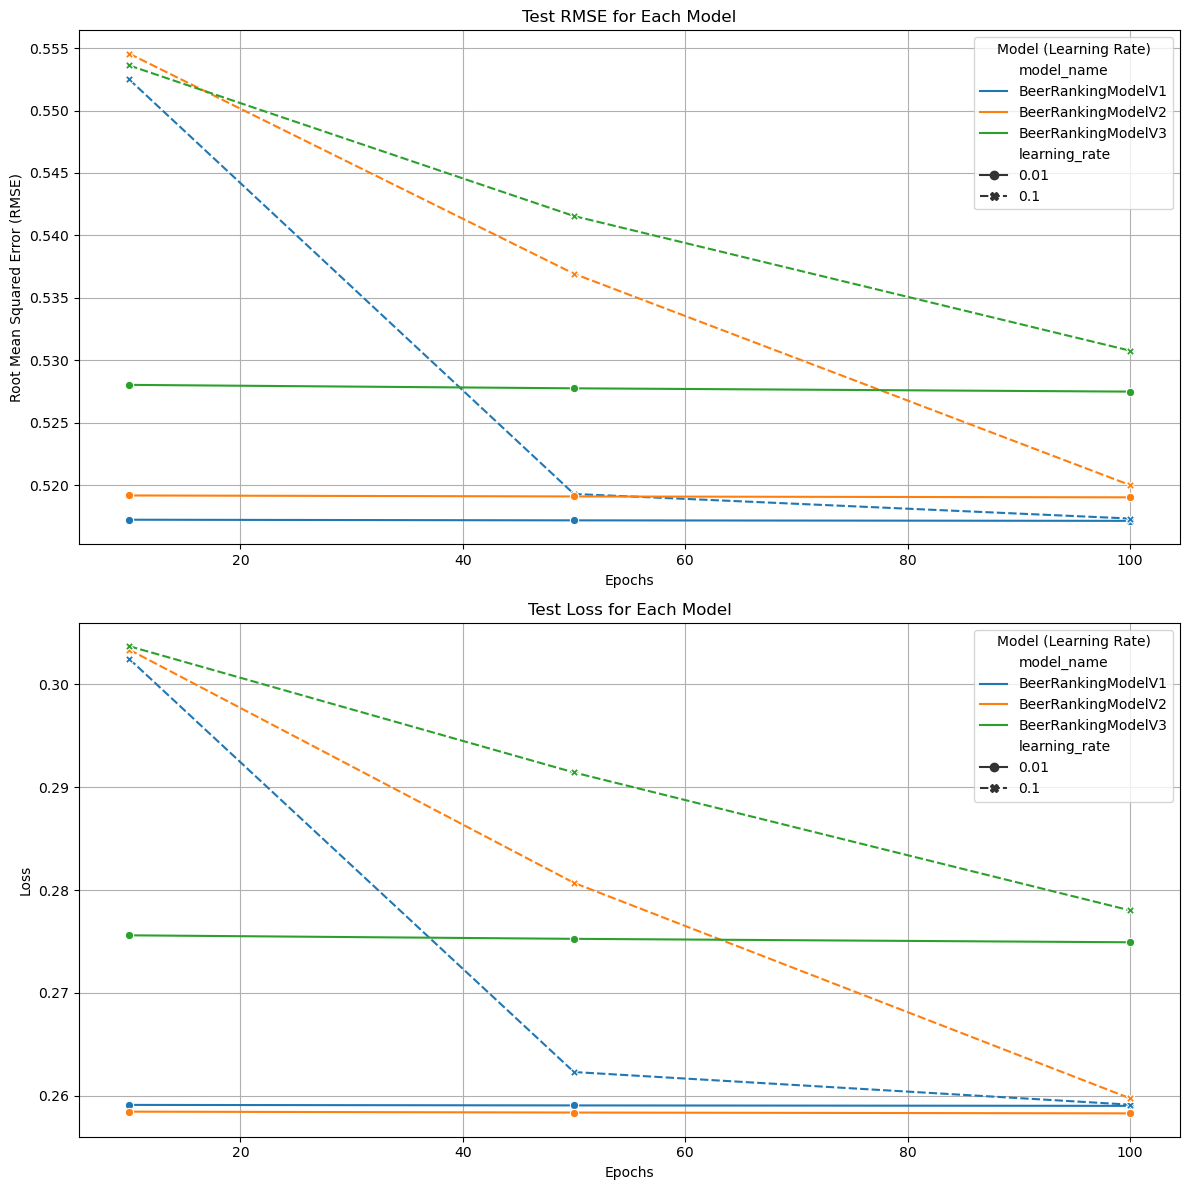

In [33]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filter out the test data
df_test_metrics = df_rankings_metrics[df_rankings_metrics['is_training'] == False]

# Creating a figure with two subplots
fig, axes = plt.subplots(nrows=2, ncols=1, figsize=(12, 12))

# Plotting Root Mean Squared Error (RMSE) for Test Data
sns.lineplot(data=df_test_metrics, x='epochs', y='root_mean_squared_error', hue='model_name', style='learning_rate', markers=True, ax=axes[0])
axes[0].set_title('Test RMSE for Each Model')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Root Mean Squared Error (RMSE)')
axes[0].grid(True)
axes[0].legend(title='Model (Learning Rate)')

# Plotting Loss for Test Data
sns.lineplot(data=df_test_metrics, x='epochs', y='loss', hue='model_name', style='learning_rate', markers=True, ax=axes[1])
axes[1].set_title('Test Loss for Each Model')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].grid(True)
axes[1].legend(title='Model (Learning Rate)')

# Display the plot
plt.tight_layout()
plt.show()


In [35]:
df_test_metrics.sort_values(by=['root_mean_squared_error', 'loss'], ascending=[True, True])

,model_name,epochs,learning_rate,root_mean_squared_error,loss,total_loss,is_training
11,BeerRankingModelV1,100,0.01,0.517141,0.259027,0.259027,False
9,BeerRankingModelV1,50,0.01,0.517182,0.259070,0.259070,False
7,BeerRankingModelV1,10,0.01,0.517233,0.259120,0.259120,False
5,BeerRankingModelV1,100,0.10,0.517329,0.259145,0.259145,False
23,BeerRankingModelV2,100,0.01,0.519025,0.258298,0.258298,False
21,BeerRankingModelV2,50,0.01,0.519096,0.258378,0.258378,False
19,BeerRankingModelV2,10,0.01,0.519176,0.258466,0.258466,False
3,BeerRankingModelV1,50,0.10,0.519295,0.262314,0.262314,False
17,BeerRankingModelV2,100,0.10,0.520009,0.259764,0.259764,False
35,BeerRankingModelV3,100,0.01,0.527492,0.274924,0.274924,False


##### Ranking model evalution
Given all the plots and statistics, v1 has the best performance (lowest root_mean_squared_error)

The best hyperparameters seems learning rate 0.01 with 30 epochs. Please note that "early stopping" avoids the model runs more than 30 epochs as it does not improve better after that. 

#### Content based filtering
In this model, we are going to calculate cosine similarities of beers among each other. The attributes of beer are beer name, beer style and beer alcohol rate (abv). Beer id is used as an index

In [41]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity

# Reset index so that it can be found through matrix
df_beers.reset_index(drop=True, inplace=True)
# Extract relevant columns
df_features = df_beers[['beer_id', 'beer_name', 'beer_style', 'beer_abv']]

# Combine text features
df_features['text_features'] = df_features['beer_name'] + ' ' + df_features['beer_style']

# Vectorize text features using TF-IDF
tfidf_vectorizer = TfidfVectorizer(stop_words='english')
text_features_matrix = tfidf_vectorizer.fit_transform(df_features['text_features'])

# Normalize numerical features
numerical_features = df_features[['beer_abv']].values
scaler = MinMaxScaler()
numerical_features_scaled = scaler.fit_transform(numerical_features)

# Combine text and numerical features
combined_features_matrix = pd.concat([
    pd.DataFrame(text_features_matrix.toarray(), columns=tfidf_vectorizer.get_feature_names_out()),
    pd.DataFrame(numerical_features_scaled, columns=['beer_abv'])
], axis=1)

# Compute cosine similarity
cosine_sim_matrix = cosine_similarity(combined_features_matrix)

def get_similar_beers(beer_id, cosine_sim_matrix, df_features, top_n=10):
    # Get index of the beer_id
    beer_index = df_features[df_features['beer_id'] == beer_id].index[0]
    
    # Get cosine similarity scores for the given beer
    sim_scores = list(enumerate(cosine_sim_matrix[beer_index]))
    
    # Sort beers based on similarity scores
    sim_scores = sorted(sim_scores, key=lambda x: x[1], reverse=True)
    
    # Get top-n similar beers
    sim_beers = sim_scores[1:top_n+1]
    
    # Get beer_ids and beer_names of similar beers
    similar_beers = [(df_features['beer_id'].iloc[i], df_features['beer_name'].iloc[i]) for i, _ in sim_beers]
    
    return similar_beers

# Example usage
beer_id = 51 
similar_beers = get_similar_beers(beer_id, cosine_sim_matrix, df_features)
print(f"Beers similar to beer {beer_id}: {similar_beers}")

Beers similar to beer 51: [(2205, 'Westmalle Dubbel'), (3022, 'Ommegang Abbey Ale'), (52, 'Chimay Triple / Blanche &#40;White&#41; / Cinq Cents'), (53, 'Chimay Bleue &#40;Blue&#41; / Grande Rserve'), (2531, 'St. Bernardus Prior 8'), (5923, 'Dogfish Head World Wide Stout 2001/2003-Present &#40;18%&#41;'), (30838, 'Stone Old Guardian &#40;Vintages 2004 and later&#41;'), (675, 'North Coast Red Seal Ale'), (422, 'Stone India Pale Ale &#40;IPA&#41;'), (690, 'Boddingtons Pub Ale &#40;Can&#41;')]


C:\Users\Baris\AppData\Local\Temp\ipykernel_46152\2811874070.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_features['text_features'] = df_features['beer_name'] + ' ' + df_features['beer_style']
